MIDI pitch vs time. Same start = chord (many keys, one clock).

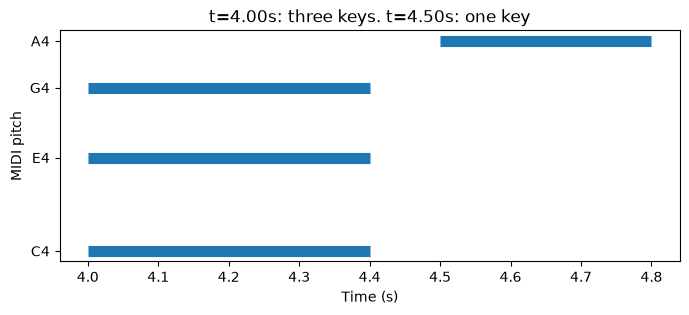

In [1]:
import matplotlib.pyplot as plt

# (pitch, start_s, end_s) — C4+E4+G4 together, then A4
notes = [(60, 4.00, 4.40), (64, 4.00, 4.40), (67, 4.00, 4.40), (69, 4.50, 4.80)]

fig, ax = plt.subplots(figsize=(8, 3))
for pitch, start, end in notes:
    ax.hlines(pitch, start, end, linewidth=8)
ax.set_xlabel("Time (s)")
ax.set_ylabel("MIDI pitch")
ax.set_yticks([60, 64, 67, 69])
ax.set_yticklabels(["C4", "E4", "G4", "A4"])
ax.set_title("t=4.00s: three keys. t=4.50s: one key")
plt.show()

Model does not see the bars above. It sees 10 ms grids: onset (start now) and hold (still down). Run after the cell above (`notes` must exist).

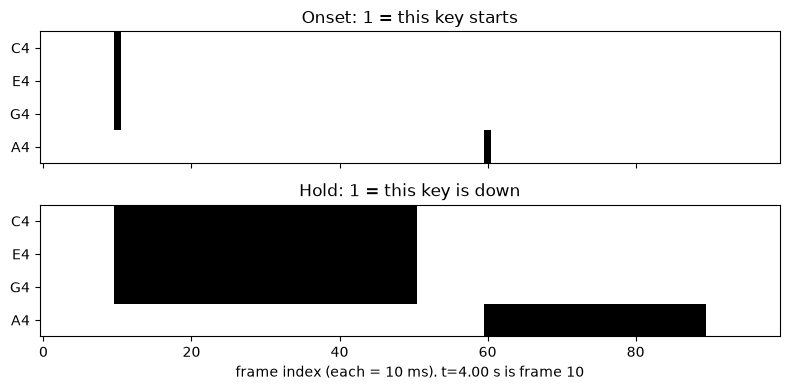

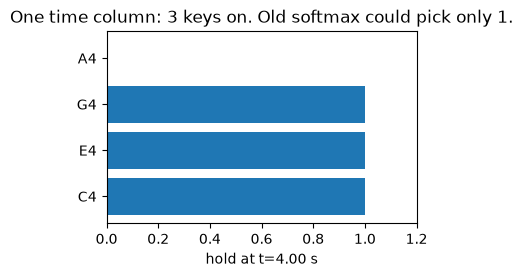

Train: given frames 0..t, predict onset+hold at t+1. Many 1s in one column is allowed.


In [2]:
import numpy as np

HOP, t0, t1 = 0.01, 3.90, 4.90
keys = [60, 64, 67, 69]
names = ["C4", "E4", "G4", "A4"]
n = int(round((t1 - t0) / HOP))
onset = np.zeros((len(keys), n))
hold = np.zeros_like(onset)
for pitch, start, end in notes:
    r = keys.index(pitch)
    s = max(int((start - t0) / HOP), 0)
    e = min(int(np.ceil((end - t0) / HOP)), n)
    if s < n:
        onset[r, s] = 1
    hold[r, s:e] = 1

fig, axes = plt.subplots(2, 1, figsize=(8, 4), sharex=True)
for ax, grid, title in zip(axes, [onset, hold], ["Onset: 1 = this key starts", "Hold: 1 = this key is down"]):
    ax.imshow(grid, aspect="auto", interpolation="nearest", cmap="Greys", vmin=0, vmax=1)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names)
    ax.set_title(title)
axes[1].set_xlabel("frame index (each = 10 ms). t=4.00 s is frame 10")
plt.tight_layout()
plt.show()

col = int((4.00 - t0) / HOP)
fig, ax = plt.subplots(figsize=(4, 2.5))
ax.barh(names, hold[:, col])
ax.set_xlim(0, 1.2)
ax.set_xlabel("hold at t=4.00 s")
ax.set_title("One time column: 3 keys on. Old softmax could pick only 1.")
plt.show()
print("Train: given frames 0..t, predict onset+hold at t+1. Many 1s in one column is allowed.")

In [3]:
# Optional: first 80 notes of a real MIDI. Skip if no file.
from pathlib import Path
p = Path("../data/maestro-v3.0.0")
files = sorted(p.glob("**/*.midi"))[:1]
if not files:
    print("No MIDI on disk. Chord cell above is enough.")
else:
    import pretty_midi as pm
    midi = pm.PrettyMIDI(str(files[0]))
    inst = next(i for i in midi.instruments if not i.is_drum)
    fig, ax = plt.subplots(figsize=(10, 3))
    for n in sorted(inst.notes, key=lambda x: x.start)[:80]:
        ax.hlines(n.pitch, n.start, n.end, linewidth=4)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("MIDI pitch")
    ax.set_title(files[0].name)
    plt.show()

No MIDI on disk. Chord cell above is enough.


Training dashboard (after a smoke run). Loss down = learning. F1 vs tau = how we turn probabilities into notes. Heatmaps = true attacks vs model belief.

In [4]:
from pathlib import Path
from IPython.display import Image, display

png = Path("../artifacts/smoke_dashboard.png")
if png.exists():
    display(Image(filename=str(png)))
else:
    print("No dashboard yet. From basic-neural-network/: python py_scripts/train_onset_frame_smoke.py")

No dashboard yet. From basic-neural-network/: python py_scripts/train_onset_frame_smoke.py
